# Data Cleaning and Price Forecasting


This notebook cleans the carbon pricing dataset, explores the data, and builds machine learning models to forecast future carbon prices.


## 1. Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


## 2. Load and Clean Data
We handle malformed lines and parse the structure properly.


In [2]:
header = ["Unique_ID", "Name", "Instrument_Type", "Region", "Income_group", "Metric"] + [str(year) for year in range(1990, 2026)]
df = pd.read_csv('Compliance_Price-Table1.csv', names=header, on_bad_lines='skip')
# Clean up garbage rows (like misplaced headers)
df = df[~df['Unique_ID'].isin(['income', 'Unique ID', 'nan'])].copy()
df = df.dropna(subset=['Unique_ID'])


## 3. Exploratory Data Analysis (EDA)


In [3]:
print("Shape:", df.shape)
print("\nInfo:")
df.info()
print("\nDescribe:")
df.describe(include='all')


Shape: (79, 42)

Info:
<class 'pandas.DataFrame'>
Index: 79 entries, 1 to 80
Data columns (total 42 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unique_ID        79 non-null     str    
 1   Name             79 non-null     str    
 2   Instrument_Type  79 non-null     str    
 3   Region           79 non-null     str    
 4   Income_group     79 non-null     str    
 5   Metric           78 non-null     str    
 6   1990             0 non-null      float64
 7   1991             0 non-null      float64
 8   1992             0 non-null      float64
 9   1993             0 non-null      float64
 10  1994             3 non-null      float64
 11  1995             3 non-null      float64
 12  1996             3 non-null      float64
 13  1997             2 non-null      float64
 14  1998             3 non-null      float64
 15  1999             5 non-null      float64
 16  2000             6 non-null      float64
 17  2001       

,Unique_ID,Name,Instrument_Type,Region,Income_group,Metric,1990,1991,1992,1993,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
count,79,79,79,79,79,78,0.0,0.0,0.0,0.0,...,39.000000,41.000000,42.000000,46.000000,50.000000,61.000000,65.000000,66.000000,67.000000,64.000000
unique,79,79,2,6,3,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Tax_DK,Denmark carbon tax,ETS,Europe & Central Asia,High income,US$/tCO2e,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,40,26,57,78,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,19.497297,20.038632,23.745346,21.693631,20.918080,24.411101,32.477630,35.113968,36.778844,39.826141
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,29.823425,26.928957,32.162894,28.853627,27.033899,27.720854,34.765411,36.031593,36.461810,40.702610
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.013668,0.015443,0.078397,0.071941,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.339995,4.571180,4.475000,4.330203,5.017226,4.874086,5.661446,8.295115,7.620966,5.484357
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.885103,13.386881,12.696917,14.582812,13.929541,17.940000,23.653800,24.013647,25.750000,24.605600
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.857437,21.382000,24.638463,23.216535,21.589383,31.834461,39.961637,48.030740,58.944887,66.211319


## 4. Reshape Data (Wide to Long)
Convert years from columns into a single 'Year' column.


In [ ]:
df_long = pd.melt(df, 
                  id_vars=["Unique_ID", "Name", "Instrument_Type", "Region", "Income_group", "Metric"], 
                  var_name="Year", 
                  value_name="Price")

df_long['Year'] = pd.to_numeric(df_long['Year'], errors='coerce')
df_long['Price'] = pd.to_numeric(df_long['Price'], errors='coerce')
df_long = df_long.dropna(subset=['Price']) # Drop missing prices

print(f"New shape after reshaping and dropping NaNs: {df_long.shape}")
df_long.head()

#pandas.melt(frame, id_vars=None, value_vars=None, var_name=None, value_name='value', ignore_index=True)


New shape after reshaping and dropping NaNs: (809, 8)


,Unique_ID,Name,Instrument_Type,Region,Income_group,Metric,Year,Price
347,Tax_NO,Norway carbon tax,Carbon tax,Europe & Central Asia,High income,US$/tCO2e,1994,99.308267
352,Tax_PL,Poland carbon tax,Carbon tax,Europe & Central Asia,High income,US$/tCO2e,1994,0.044053
366,Tax_SE,Sweden carbon tax,Carbon tax,Europe & Central Asia,High income,US$/tCO2e,1994,43.433827
426,Tax_NO,Norway carbon tax,Carbon tax,Europe & Central Asia,High income,US$/tCO2e,1995,115.810756
431,Tax_PL,Poland carbon tax,Carbon tax,Europe & Central Asia,High income,US$/tCO2e,1995,0.055319


## 5. Visualizations


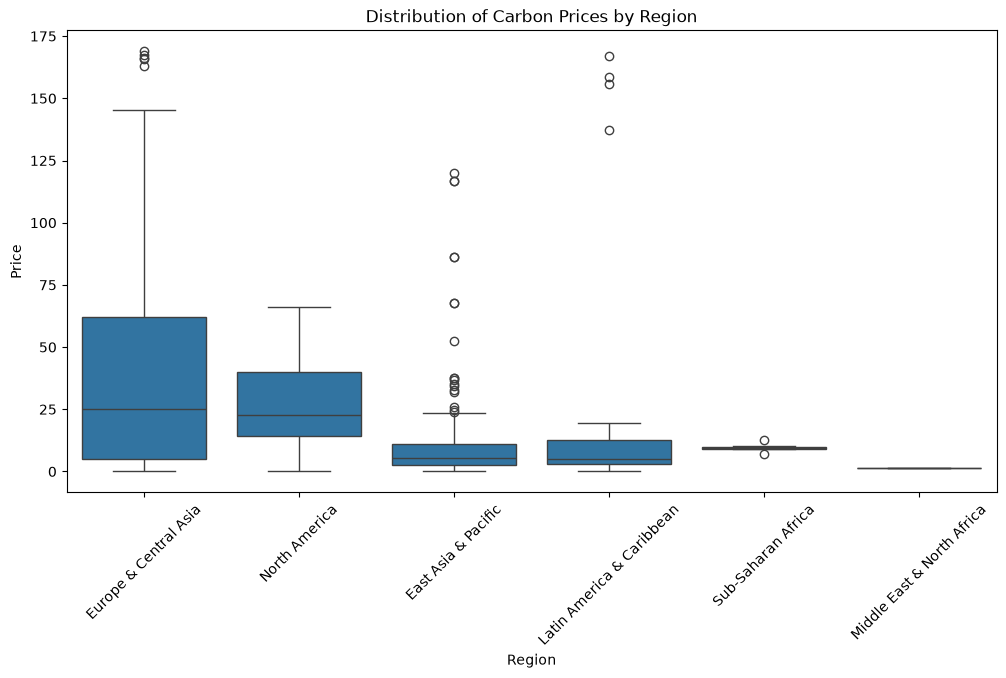

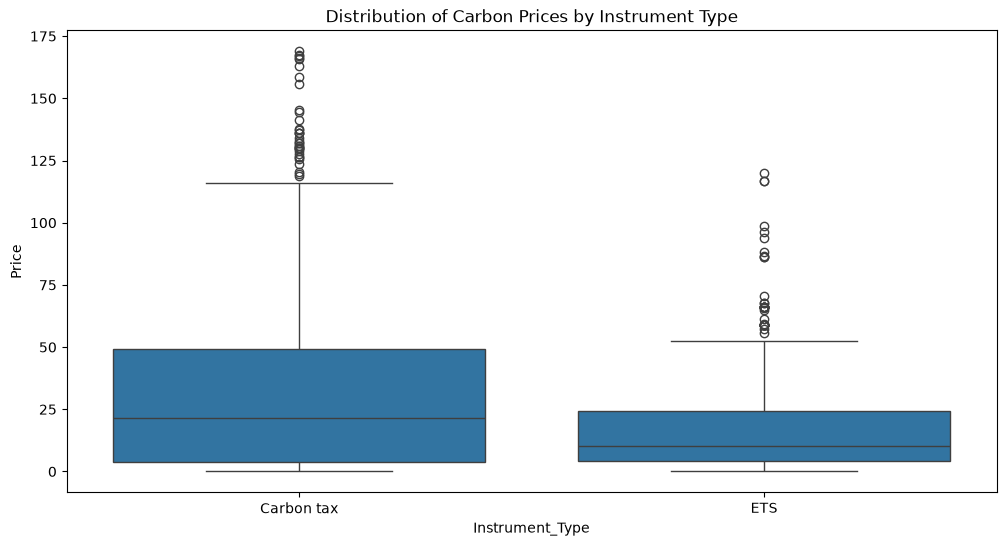

In [5]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Region', y='Price', data=df_long)
plt.xticks(rotation=45)
plt.title('Distribution of Carbon Prices by Region')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x='Instrument_Type', y='Price', data=df_long)
plt.title('Distribution of Carbon Prices by Instrument Type')
plt.show()


## 6. Outlier Removal (IQR Method)


In [6]:
Q1 = df_long['Price'].quantile(0.25)
Q3 = df_long['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df_long[(df_long['Price'] >= lower_bound) & (df_long['Price'] <= upper_bound)].copy()
print(f"Removed {len(df_long) - len(df_clean)} outliers. Clean data shape: {df_clean.shape}")


Removed 68 outliers. Clean data shape: (741, 8)


## 7. Model Preparation
We create a 'Next_Year_Price' target variable to formulate the forecasting task.


In [7]:
# Create a feature 'Next_Year_Price' by shifting the data per initiative
df_clean = df_clean.sort_values(by=['Unique_ID', 'Year'])
df_clean['Next_Year_Price'] = df_clean.groupby('Unique_ID')['Price'].shift(-1)

# Drop rows where we don't have a next year's price to predict
model_df = df_clean.dropna(subset=['Next_Year_Price']).copy()

X = model_df[['Instrument_Type', 'Region', 'Income_group', 'Year', 'Price']]
y = model_df['Next_Year_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape)


Training set shape: (533, 5)


## 8. Evaluate 3 Models
We evaluate Linear Regression, Random Forest, and Gradient Boosting. We use StandardScaler for numerical features.


In [8]:
categorical_features = ['Instrument_Type', 'Region', 'Income_group']
numeric_features = ['Year', 'Price']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'RMSE': rmse, 'R2': r2}
    print(f"{name}: RMSE={rmse:.2f}, R2={r2:.2f}")


Linear Regression: RMSE=11.71, R2=0.72


Random Forest: RMSE=11.01, R2=0.75
Gradient Boosting: RMSE=11.09, R2=0.75


## 9. Final Model Training & Export
We train the final model on the full data and export it to a `.pkl` file.


/var/folders/7x/p7jtyjns1sg28942rqwdmjn00000gn/T/ipykernel_11581/3627109130.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=r2_scores, palette='viridis')


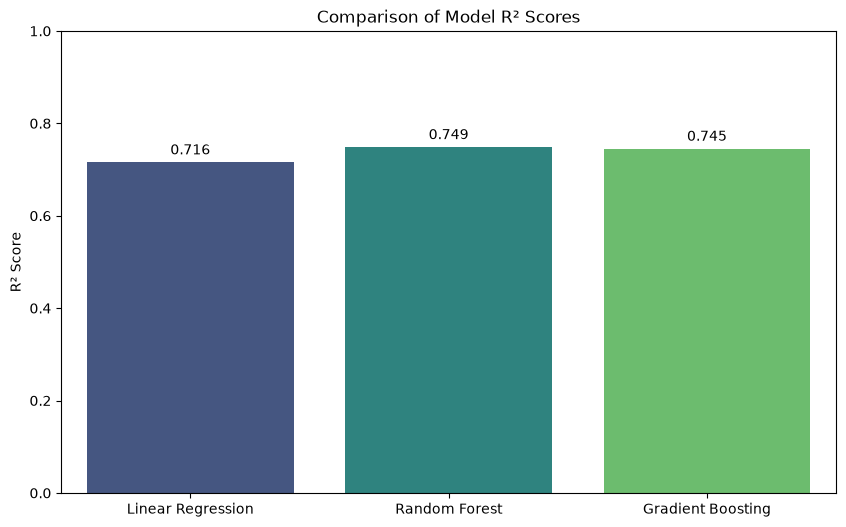

Final Model (Gradient Boosting) R^2 Score on Test Data: 0.7450884613377555
Model saved to carbon_model.pkl successfully!


In [9]:
# Plot the R2 Scores of different models
model_names = list(results.keys())
r2_scores = [results[name]['R2'] for name in model_names]

plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=r2_scores, palette='viridis')
plt.title('Comparison of Model R² Scores')
plt.ylabel('R² Score')

# Set y-limit with a bit of padding above the max score
max_score = max(r2_scores)
plt.ylim(0, max(1.0, max_score + 0.1) if max_score > 0 else 1.0) 

for i, v in enumerate(r2_scores):
    plt.text(i, max(0, v) + 0.01, f"{v:.3f}", ha='center', va='bottom')
plt.show()

# Train final model
best_pipeline = Pipeline(steps=[('preprocessor', preprocessor), 
                                ('model', GradientBoostingRegressor(n_estimators=100, random_state=42))])
best_pipeline.fit(X_train, y_train)
final_preds = best_pipeline.predict(X_test)
print("Final Model (Gradient Boosting) R^2 Score on Test Data:", r2_score(y_test, final_preds))

# Save the trained model to a .pkl file
joblib.dump(best_pipeline, 'carbon_model.pkl')
print("Model saved to carbon_model.pkl successfully!")



In [10]:
model_df.to_csv('cleaned_dataset.csv', index=False)
df.to_csv('unclean_dataset.csv', index=False)